# Color 05 - Dashboard color audit and redesign (Solution)

Muc tieu: tu mot bo chart mau chua tot -> redesign co co so.

In [1]:
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def resolve_repo_root() -> Path:
    cwd = Path.cwd().resolve()
    for p in [cwd, *cwd.parents]:
        if (p / "data" / "gapminder.csv").exists():
            return p
    raise FileNotFoundError("Cannot locate data/gapminder.csv")

root = resolve_repo_root()
df = pd.read_csv(root / "data" / "gapminder.csv")
d2007 = df[df["year"]==2007].copy()

## 1) Baseline "bad" version (co y de thay van de)

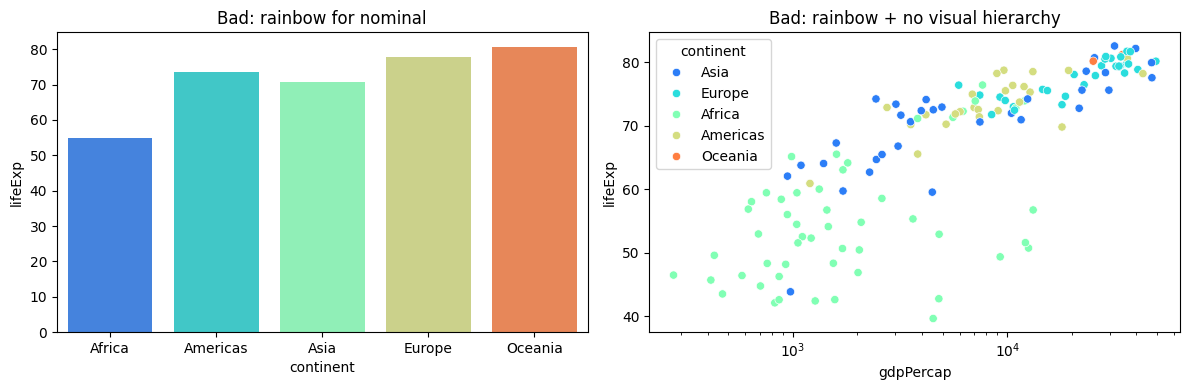

In [2]:
fig, axes = plt.subplots(1,2, figsize=(12,4))
sns.barplot(data=d2007.groupby("continent",as_index=False)["lifeExp"].mean(), x="continent", y="lifeExp", hue="continent", palette="rainbow", ax=axes[0])
axes[0].set_title("Bad: rainbow for nominal")

sns.scatterplot(data=d2007, x="gdpPercap", y="lifeExp", hue="continent", palette="rainbow", ax=axes[1])
axes[1].set_xscale("log")
axes[1].set_title("Bad: rainbow + no visual hierarchy")
plt.tight_layout(); plt.show()

## 2) Redesigned version

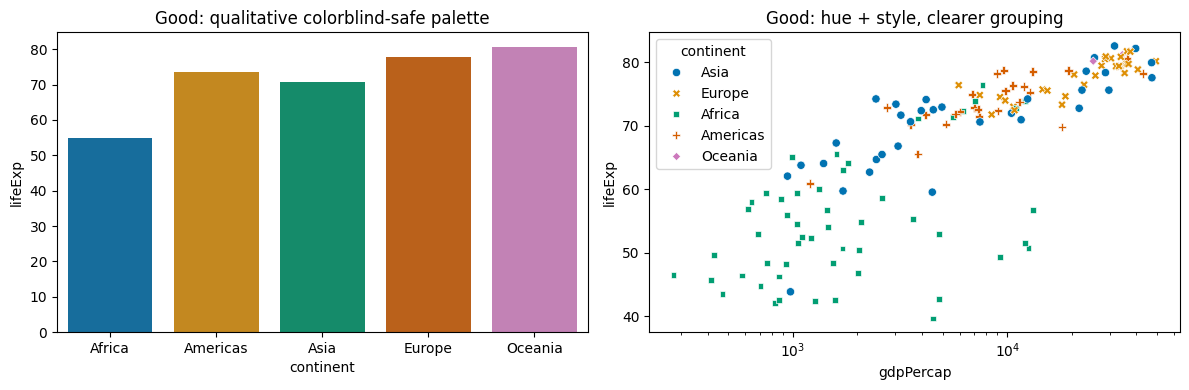

In [3]:
fig, axes = plt.subplots(1,2, figsize=(12,4))
sns.barplot(data=d2007.groupby("continent",as_index=False)["lifeExp"].mean(), x="continent", y="lifeExp", hue="continent", palette="colorblind", ax=axes[0])
axes[0].set_title("Good: qualitative colorblind-safe palette")

sns.scatterplot(data=d2007, x="gdpPercap", y="lifeExp", hue="continent", style="continent", palette="colorblind", ax=axes[1])
axes[1].set_xscale("log")
axes[1].set_title("Good: hue + style, clearer grouping")
plt.tight_layout(); plt.show()

## 3) Audit checklist (dien vao bai nop)
- Data type -> palette type co dung khong?
- Co color-blind fallback (shape/label) khong?
- Co dung >6 mau category khong can thiet khong?
- Co dung rainbow cho continuous ma khong co ly do dac biet khong?

## Reflection
Viet 8-10 cau: truoc/sau redesign thay doi gi ve kha nang doc insight.